# Machine Learning 
House Rent Prediction Dataset

This notebook follows the same learning pattern as the original  notebook, but the real-world dataset has been  **house-rent data**. The goal is to understand data handling, EDA, preprocessing, encoding, feature engineering, and scaling before model training.

**Dataset:** House Rent Prediction Dataset

**Kaggle link:** https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset

**Problem type:** Supervised Machine Learning → **Regression**

**Target:** `Rent` — monthly house rent.

**Important:**  Focus on understanding and preparing the data. We do not train the final prediction model yet.


## 0. Kaggle environment setup

Kaggle attaches the dataset directly to the notebook. Use **Add Input** and attach the House Rent Prediction Dataset. The CSV will normally appear somewhere under `/kaggle/input/`.

We use `os.walk()` so the notebook can find the CSV without hardcoding the Kaggle folder name.


In [1]:
import os

dataset_paths = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        full_path = os.path.join(dirname, filename)
        print(full_path)
        if filename.lower().endswith('.csv'):
            dataset_paths.append(full_path)

assert dataset_paths, 'No CSV found. Click Add Input and attach the House Rent Prediction Dataset.'
print('CSV files found:', len(dataset_paths))


/kaggle/input/datasets/iamsouravbanerjee/house-rent-prediction-dataset/Dataset Glossary.txt
/kaggle/input/datasets/iamsouravbanerjee/house-rent-prediction-dataset/House_Rent_Dataset.csv
CSV files found: 1


## 1. Environment & core libraries

| Library | Purpose in this project |
|---|---|
| **NumPy** | Numerical arrays and mathematical operations |
| **Pandas** | Load, clean, filter, group and analyze the rental table |
| **Matplotlib** | Basic charts such as histograms, scatter plots and bar charts |
| **Seaborn** | Statistical visualizations such as box plots and heatmaps |
| **Scikit-learn** | Encoding and scaling now; model training will come later |

The important change from the previous notebook is that every example below uses **property/rent concepts**, not music concepts.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

sns.set_style('whitegrid')
print('NumPy version:', np.__version__)
print('Pandas version:', pd.__version__)


NumPy version: 2.0.2
Pandas version: 2.3.3


## 2. NumPy fundamentals — arrays, indexing, reshaping, broadcasting and aggregations

Before working with the real rental table, practice the NumPy operations that later appear inside ML preprocessing.


In [3]:
# Example rental-related numerical values: monthly rents in rupees
rents = np.array([12000, 15000, 18000, 22000, 25000, 30000])

print('Rent array:', rents)
print('First rent:', rents[0])
print('Last rent:', rents[-1])
print('First three rents:', rents[0:3])
print('Mean rent:', rents.mean())
print('Standard deviation:', rents.std())
print('Total:', rents.sum())
print('Index of highest rent:', rents.argmax())


Rent array: [12000 15000 18000 22000 25000 30000]
First rent: 12000
Last rent: 30000
First three rents: [12000 15000 18000]
Mean rent: 20333.333333333332
Standard deviation: 6073.622386096199
Total: 122000
Index of highest rent: 5


In [4]:
# Reshape six rent values into a 2 × 3 matrix
rent_matrix = rents.reshape(2, 3)

print('2 x 3 rent matrix:\n', rent_matrix)

# Broadcasting: add ₹1,000 to every value at once
print('After adding ₹1,000:\n', rent_matrix + 1000)

print('Column-wise sum:', rent_matrix.sum(axis=0))
print('Row-wise sum:', rent_matrix.sum(axis=1))


2 x 3 rent matrix:
 [[12000 15000 18000]
 [22000 25000 30000]]
After adding ₹1,000:
 [[13000 16000 19000]
 [23000 26000 31000]]
Column-wise sum: [34000 40000 48000]
Row-wise sum: [45000 77000]


## 3. Loading the real House Rent dataset — Pandas Series & DataFrame

A **Series** is one labeled column. A **DataFrame** is the complete table.

The important columns in this dataset include property information such as `BHK`, `Rent`, `Size`, `Floor`, `Area Type`, `Area Locality`, `City`, `Furnishing Status`, `Tenant Preferred`, `Bathroom`, and `Point of Contact`.


In [5]:
# Use the CSV discovered by os.walk().
df = pd.read_csv(dataset_paths[0])

# Remove accidental CSV index columns if present.
unnamed_cols = [c for c in df.columns if c.lower().startswith('unnamed')]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())


Shape: (4746, 12)
Columns: ['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']


In [6]:
# First five rental records
df.head()


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [7]:
# A single column is a pandas Series.
rent_series = df['Rent']
print(type(rent_series))
rent_series.head()


<class 'pandas.core.series.Series'>


0    10000
1    20000
2    17000
3    10000
4     7500
Name: Rent, dtype: int64

## 4. Structured data, features and target

This is **structured tabular data** because every property is represented by rows and columns.

### Target
`Rent` is the **target** because our future model will predict the monthly rental amount.

### Features
Examples of features are `BHK`, `Size`, `Bathroom`, `City`, `Furnishing Status`, `Area Type`, and `Tenant Preferred`.

Because `Rent` is a continuous numerical value, this is a **regression problem**, not a classification problem.


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [9]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Posted On,4746,81,2022-07-06,311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BHK,4746.0,NaN,NaN,NaN,2.08386,0.832256,1.0,2.0,2.0,3.0,6.0
Rent,4746.0,NaN,NaN,NaN,34993.451327,78106.412937,1200.0,10000.0,16000.0,33000.0,3500000.0
Size,4746.0,NaN,NaN,NaN,967.490729,634.202328,10.0,550.0,850.0,1200.0,8000.0
Floor,4746,480,1 out of 2,379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Type,4746,3,Super Area,2446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Locality,4746,2235,Bandra West,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,4746,6,Mumbai,972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Furnishing Status,4746,3,Semi-Furnished,2251,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenant Preferred,4746,3,Bachelors/Family,3444,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Pandas — loc/iloc, filtering, groupby and merge/join

We now apply the same Pandas concepts to property data.
- `loc` selects using labels/column names.
- `iloc` selects using integer positions.
- Filtering keeps properties satisfying a condition.
- `groupby` summarizes rent by a category such as city.
- `merge` combines related tables when a project has multiple datasets.


In [10]:
# loc: first three rows and useful property columns
cols = [c for c in ['City', 'BHK', 'Size', 'Rent'] if c in df.columns]
df.loc[0:2, cols]


,City,BHK,Size,Rent
0,Kolkata,2,1100,10000
1,Kolkata,2,800,20000
2,Kolkata,2,1000,17000


In [11]:
# iloc: first three rows and first four columns
df.iloc[0:3, 0:4]


,Posted On,BHK,Rent,Size
0,2022-05-18,2,10000,1100
1,2022-05-13,2,20000,800
2,2022-05-16,2,17000,1000


In [12]:
# Filtering: properties with rent above the dataset median
median_rent = df['Rent'].median()
high_rent_houses = df[df['Rent'] > median_rent]
print('Median rent:', median_rent)
print('Properties above median rent:', high_rent_houses.shape[0])

# Multiple conditions: larger properties with higher-than-median rent
large_and_expensive_houses = df[(df['Size'] > df['Size'].median()) & (df['Rent'] > median_rent)]
print('Large + above-median-rent properties:', large_and_expensive_houses.shape[0])


Median rent: 16000.0
Properties above median rent: 2298
Large + above-median-rent properties: 1530


In [13]:
# Groupby: average rent by city
avg_rent_by_city = df.groupby('City')['Rent'].mean().sort_values(ascending=False)
avg_rent_by_city.head(10)


City
Mumbai       85321.204733
Delhi        29461.983471
Bangalore    24966.365688
Chennai      21614.092031
Hyderabad    20555.048387
Kolkata      11645.173664
Name: Rent, dtype: float64

In [14]:
# Example merge: a small city-level summary table can be joined back to properties.
city_summary = df.groupby('City', as_index=False)['Rent'].mean().rename(columns={'Rent': 'City_Average_Rent'})
merged_demo = df[['City', 'Rent']].merge(city_summary, on='City', how='left')
merged_demo.head()


,City,Rent,City_Average_Rent
0,Kolkata,10000,11645.173664
1,Kolkata,20000,11645.173664
2,Kolkata,17000,11645.173664
3,Kolkata,10000,11645.173664
4,Kolkata,7500,11645.173664


## 6. Visualization — understanding rent before modeling

Good visualizations answer questions such as:
- What does the rent distribution look like?
- Does larger property size generally relate to higher rent?
- Which cities have higher average rent?
- Are there extreme rent values that need investigation?


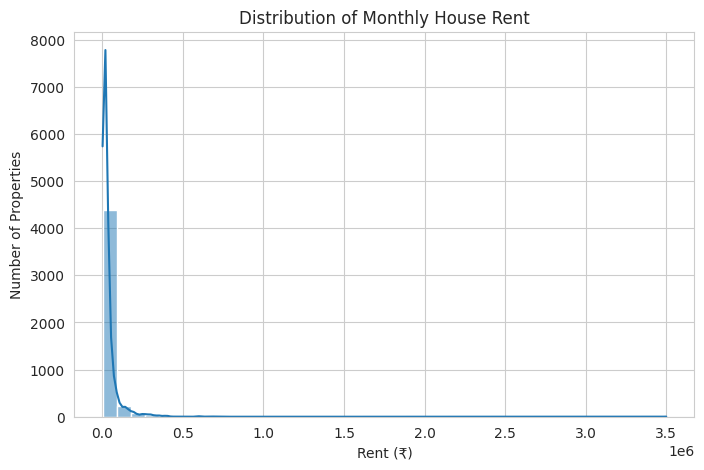

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Rent'].dropna(), bins=40, kde=True)
plt.title('Distribution of Monthly House Rent')
plt.xlabel('Rent (₹)')
plt.ylabel('Number of Properties')
plt.show()


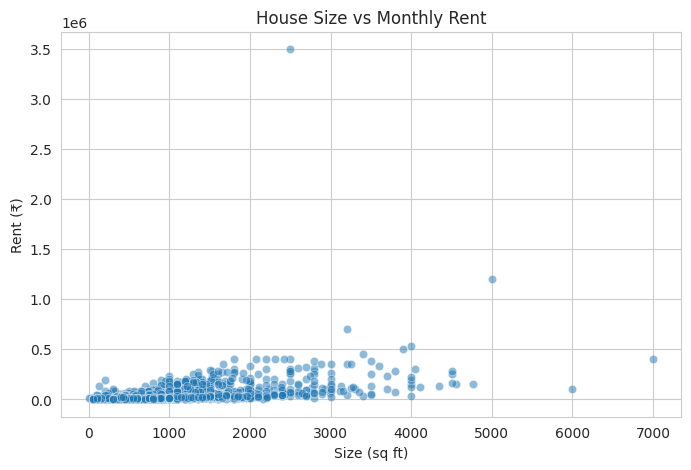

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(min(3000, len(df)), random_state=42), x='Size', y='Rent', alpha=0.5)
plt.title('House Size vs Monthly Rent')
plt.xlabel('Size (sq ft)')
plt.ylabel('Rent (₹)')
plt.show()


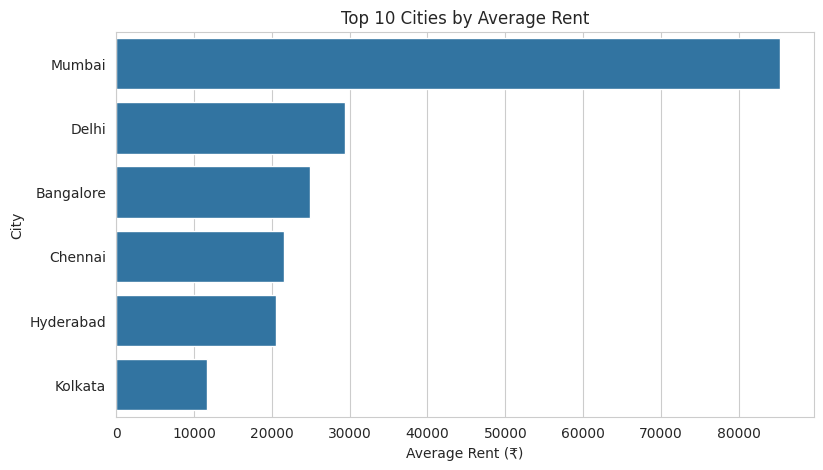

In [17]:
top_city_rent = df.groupby('City')['Rent'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(9, 5))
sns.barplot(x=top_city_rent.values, y=top_city_rent.index)
plt.title('Top 10 Cities by Average Rent')
plt.xlabel('Average Rent (₹)')
plt.ylabel('City')
plt.show()


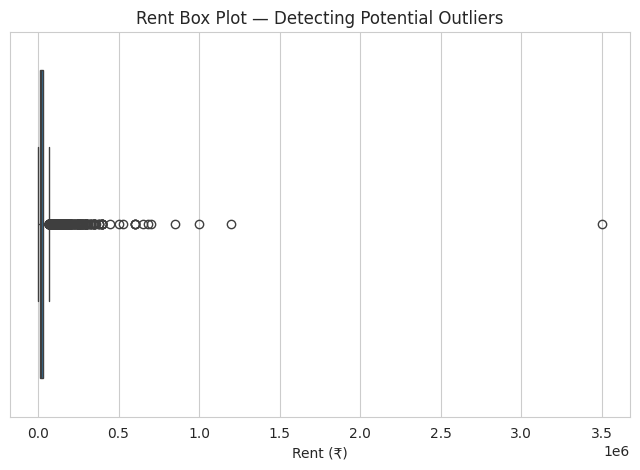

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Rent'].dropna())
plt.title('Rent Box Plot — Detecting Potential Outliers')
plt.xlabel('Rent (₹)')
plt.show()


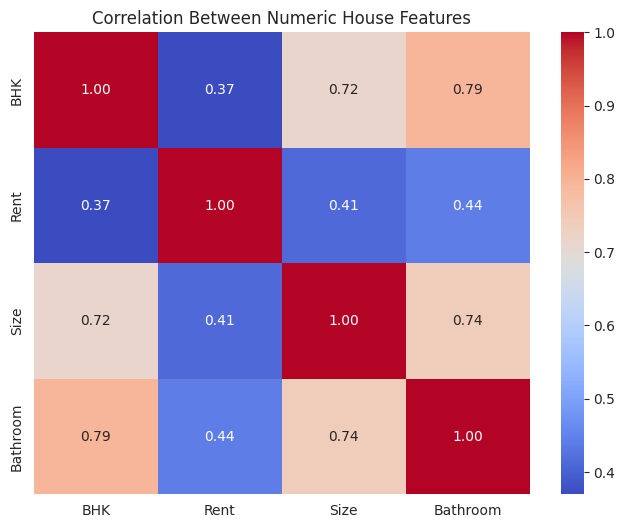

In [19]:
numeric_cols = df.select_dtypes(include=np.number)
corr = numeric_cols.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Between Numeric House Features')
plt.show()


## 7. EDA conclusions

From the charts, focus on relationships that are meaningful for rent prediction. `Size`, `BHK`, `Bathroom`, and location-related categories can provide useful information. The rent distribution may also contain extreme values, so outlier analysis is important.

**Important representation:** Do not call `Rent` a feature. It is the **target**. The other property attributes are candidate features.


In [20]:
print('Rows:', len(df))
print('Columns:', len(df.columns))
print('Missing values:', int(df.isnull().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))


Rows: 4746
Columns: 12
Missing values: 0
Duplicate rows: 0


## 8. Data preprocessing — missing values, duplicates and outliers

Cleaning must be done carefully. We should not blindly delete every unusual house because a high-rent property can be real. We first identify suspicious values, then decide how to handle them.


In [21]:
df.isnull().sum().sort_values(ascending=False).head(15)


Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [22]:
# Core prediction columns should not be missing.
core_cols = [c for c in ['Rent', 'Size', 'BHK', 'Bathroom', 'City'] if c in df.columns]
print('Core columns:', core_cols)

# Remove rows missing the target; feature missing values can be handled later.
df = df.dropna(subset=['Rent']).copy()
print('Missing target values after cleaning:', df['Rent'].isnull().sum())


Core columns: ['Rent', 'Size', 'BHK', 'Bathroom', 'City']
Missing target values after cleaning: 0


In [23]:
print('Duplicate rows found:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after duplicates:', df.shape)


Duplicate rows found: 0
Shape after duplicates: (4746, 12)


In [24]:
# IQR outlier detection for Rent
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

rent_outliers = df[(df['Rent'] < lower_bound) | (df['Rent'] > upper_bound)]
print(f'Rent outliers: {len(rent_outliers)} rows')
print(f'Normal statistical range: ₹{lower_bound:,.0f} to ₹{upper_bound:,.0f}')


Rent outliers: 520 rows
Normal statistical range: ₹0 to ₹67,500


## 9. Encoding — converting categorical house information into numbers

Machine-learning algorithms generally require numerical inputs. House-rent data contains categories such as city, area type, furnishing status and tenant preference.

- **Label encoding:** useful for a simple binary/ordered category.
- **One-hot encoding:** appropriate for nominal categories such as cities.
- **Ordinal encoding:** appropriate when the categories have a real order.

For this project, one-hot encoding is generally safer for `City` because Bengaluru, Mumbai, Chennai, etc. do not have a natural numeric order.


In [25]:
# Label encoding example for furnishing status (demonstration only).
le = LabelEncoder()
demo = df[['Furnishing Status']].dropna().copy()
demo['furnishing_encoded'] = le.fit_transform(demo['Furnishing Status'])
demo.drop_duplicates().sort_values('furnishing_encoded')


,Furnishing Status,furnishing_encoded
12,Furnished,0
1,Semi-Furnished,1
0,Unfurnished,2


In [26]:
# One-hot encode a few major categorical columns.
cat_cols = [c for c in ['Area Type', 'Furnishing Status', 'Tenant Preferred'] if c in df.columns]
encoded_demo = pd.get_dummies(df[cat_cols].head(10), columns=cat_cols, dtype=int)
encoded_demo.head()


,Area Type_Carpet Area,Area Type_Super Area,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors,Tenant Preferred_Bachelors/Family
0,0,1,0,1,0,1
1,0,1,1,0,0,1
2,0,1,1,0,0,1
3,0,1,0,1,0,1
4,1,0,0,1,1,0


In [27]:
# Ordinal encoding example: furnishing level has a meaningful rough order.
furnishing_order = {'Unfurnished': 0, 'Semi-Furnished': 1, 'Fully Furnished': 2}
if 'Furnishing Status' in df.columns:
    ordinal_demo = df['Furnishing Status'].map(furnishing_order)
    print(ordinal_demo.head())


0    0.0
1    1.0
2    1.0
3    0.0
4    0.0
Name: Furnishing Status, dtype: float64


## 10. Feature engineering & feature selection

**Feature engineering** creates a more informative variable from existing data.

For rent prediction, a useful example is **rent per square foot** for EDA. However, there is an important modeling rule: because `Rent` is the target, **we must not use actual Rent to create a feature for predicting Rent**. Therefore, we use a size-based feature such as `BHK_per_1000_sqft` or other features derived only from input variables.


In [28]:
# Feature engineering using only input variables — no target leakage.
df['size_per_bhk'] = df['Size'] / df['BHK'].replace(0, np.nan)
df['bathroom_per_bhk'] = df['Bathroom'] / df['BHK'].replace(0, np.nan)

df[['Size', 'BHK', 'Bathroom', 'size_per_bhk', 'bathroom_per_bhk']].head()


,Size,BHK,Bathroom,size_per_bhk,bathroom_per_bhk
0,1100,2,2,550.0,1.0
1,800,2,1,400.0,0.5
2,1000,2,1,500.0,0.5
3,800,2,1,400.0,0.5
4,850,2,1,425.0,0.5


## 11. Imbalanced data — is it relevant here?

Class imbalance techniques such as oversampling, undersampling and SMOTE are mainly used for **classification**, where the target contains classes such as `Yes/No`.

Our target `Rent` is continuous, so this house-rent regression task does **not** have class imbalance in the usual sense. Do not apply SMOTE just because it was present in the previous House Rent notebook.

If we later convert rent into categories such as `Low`, `Medium`, and `High`, then class imbalance could become relevant.


In [29]:
# Show why Rent is a regression target: it has many numeric values rather than a few classes.
print('Unique rent values:', df['Rent'].nunique())
print('Target dtype:', df['Rent'].dtype)
print(df['Rent'].describe())


Unique rent values: 243
Target dtype: int64
count    4.746000e+03
mean     3.499345e+04
std      7.810641e+04
min      1.200000e+03
25%      1.000000e+04
50%      1.600000e+04
75%      3.300000e+04
max      3.500000e+06
Name: Rent, dtype: float64


## 12. Train/test split, validation, cross-validation and data leakage

These are concepts for the next stage of the project:
- **Train/test split:** train on one portion and evaluate on unseen properties.
- **Validation:** use a separate portion while tuning the model.
- **Cross-validation:** repeat training/evaluation over several folds.
- **Data leakage:** never allow information from the test set or the target to sneak into the input features.

A major example of leakage here would be creating a feature directly from the actual `Rent` and then asking the model to predict `Rent`.


## 13. Scaling — standardization vs normalization

House-rent features can have very different numerical ranges: `BHK` may be a small integer, `Size` may be thousands of square feet, and `Bathroom` may be another small integer. Scaling can put numeric features on comparable ranges for algorithms that are sensitive to feature magnitude.

- **Standardization:** mean ≈ 0 and standard deviation ≈ 1.
- **Normalization:** maps values to the [0, 1] range.

Fit the scaler on the **training data only** when we start modeling, so the test set does not leak into preprocessing.


In [30]:
scale_cols = [c for c in ['BHK', 'Size', 'Bathroom'] if c in df.columns]
scale_cols = [c for c in scale_cols if pd.api.types.is_numeric_dtype(df[c])]

standard_scaled = StandardScaler().fit_transform(df[scale_cols].fillna(df[scale_cols].median()))
normalized_scaled = MinMaxScaler().fit_transform(df[scale_cols].fillna(df[scale_cols].median()))

comparison = pd.DataFrame()
if 'Size' in scale_cols:
    comparison['Size_raw'] = df['Size'].values[:5]
    comparison['Size_standardized'] = standard_scaled[:5, scale_cols.index('Size')]
    comparison['Size_normalized'] = normalized_scaled[:5, scale_cols.index('Size')]
comparison


,Size_raw,Size_standardized,Size_normalized
0,1100,0.208960,0.136421
1,800,-0.264125,0.098874
2,1000,0.051265,0.123905
3,800,-0.264125,0.098874
4,850,-0.185277,0.105131


In [31]:
# Final feature-vector demonstration: only input variables, never Rent.
feature_cols = [c for c in ['BHK', 'Size', 'Bathroom', 'size_per_bhk', 'bathroom_per_bhk'] if c in df.columns]
X = df[feature_cols].replace([np.inf, -np.inf], np.nan).dropna()
X_scaled = StandardScaler().fit_transform(X)

print('Input feature names:', feature_cols)
print('One property as RAW feature vector:')
print(X.iloc[0].values)
print('\nSame property as SCALED feature vector:')
print(X_scaled[0])
print('\nTarget kept separately: Rent')


Input feature names: ['BHK', 'Size', 'Bathroom', 'size_per_bhk', 'bathroom_per_bhk']
One property as RAW feature vector:
[2.0e+00 1.1e+03 2.0e+00 5.5e+02 1.0e+00]

Same property as SCALED feature vector:
[-0.10077301  0.2089605   0.03859399  0.43268876  0.09434576]

Target kept separately: Rent
